# Photon-Pair Generation via SPDC: An Interactive Tutorial

This notebook simulates **spontaneous parametric down-conversion (SPDC)** with `photonpairlab`,
introducing the physics as it becomes relevant to the code, rather than as a wall of theory up
front. By the end you will have:

1. Built a periodically-poled (quasi-phase-matched) crystal and simulated its joint spectral
   amplitude (JSA)
2. Quantified its heralded-photon purity via Schmidt decomposition
3. Fixed the purity with sub-coherence-length nonlinearity apodization
4. Compared the resulting Hong-Ou-Mandel (HOM) interference dips
5. Tuned a crystal's temperature to hit a target degenerate wavelength
6. Built an angle-phase-matched (birefringent) crystal, for contrast with QPM

Each section pairs a short piece of theory with the code that puts it into practice.

## What is SPDC?

In **spontaneous parametric down-conversion**, a pump photon at frequency $\omega_p$ occasionally
splits inside a $\chi^{(2)}$ nonlinear crystal into two lower-energy photons, conventionally called
**signal** ($\omega_s$) and **idler** ($\omega_i$). Energy conservation fixes

$$\omega_p = \omega_s + \omega_i .$$

Momentum conservation is the harder constraint: the photons' wavevectors must satisfy
$k_p = k_s + k_i$ inside the dispersive crystal. Because the refractive index depends on both
wavelength and polarization, this doesn't happen automatically — the **phase mismatch**

$$\Delta k = k_p - k_s - k_i$$

has to be engineered to (near) zero for photon pairs to build up coherently as they propagate
through the crystal. Everything below is about how `photonpairlab` computes and controls
$\Delta k$, and what happens to the emitted photons when it isn't controlled well enough. For a broader introduction to SPDC theory and applications than we have room for here, see the review by Couteau **[[1]](#ref1)**.

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

from photonpairlab import (
    Crystal,
    HOMAnalyzer,
    MaterialFactory,
    PulsedLaser,
    SPDC_Plotter,
    SPDC_Simulation,
    SPDCGridConfig,
    SpectralAnalyzer,
    simulate_spdc
)
from photonpairlab.spdc.analysis import (
    quadratic,
    quadratic_fit,
    quadratic_intersection_coordinates,
)

warnings.filterwarnings("ignore")

## Two ways to fix the phase mismatch

Real crystals are *birefringent* (the refractive index depends on polarization), which gives two
classic routes to $\Delta k \approx 0$:

- **Angle phase-matching (APM):** choose signal/idler/pump polarizations and a propagation angle
  through the crystal so birefringence exactly cancels the material's normal dispersion. No poling
  needed, but the achievable wavelength/angle combinations are constrained by the crystal's
  intrinsic birefringence, and differently-polarized beams can walk off from each other spatially.
- **Quasi-phase-matching (QPM):** instead of matching $\Delta k$ exactly, periodically flip the
  crystal's nonlinear axis (its ferroelectric domains) every **coherence length**
  $$L_c = \frac{\pi}{|\Delta k|},$$
  so the effective nonlinearity resets sign right when the pump/signal/idler fields would
  otherwise start dephasing. This adds a grating wavevector to the phase-matching condition
  (grating period $\Lambda = 2 L_c$), and works for essentially any $\Delta k$ your poling process
  can physically resolve.

We'll build a QPM crystal first, since it's the more flexible and more commonly used technique for
telecom-wavelength sources — and revisit APM near the end for contrast. (Couteau **[[1]](#ref1)** also covers both routes in more depth.)

In [3]:
material = MaterialFactory.create("ktp1")   # potassium titanyl phosphate
pump_wavelength = 775e-9                     # -> degenerate 1550 nm telecom photons
pulse_duration = 1.7e-12                     # ~1.7 ps transform-limited pump pulse
crystal_length = 30e-3                       # a fairly standard 30 mm KTP crystal

laser = PulsedLaser(pump_wavelength, pulse_duration=pulse_duration)

# We don't have to supply a coherence length by hand -- a Crystal can compute the one
# that's actually correct for its own material, temperature, and target wavelengths.
crystal = Crystal(crystal_length=crystal_length, material=material,
                   pm_strategy="quasi", spdc_type="type-II", T=20.0)

Lc = crystal.ideal_coherence_length(laser, wavelength_signal=1550e-9, wavelength_idler=1550e-9)
print(f"Ideal coherence length for degenerate 1550 nm type-II SPDC in KTP at 20 C: {Lc*1e6:.3f} um")
print(f"-> QPM grating period Lambda = 2*Lc = {2*Lc*1e6:.3f} um")

Ideal coherence length for degenerate 1550 nm type-II SPDC in KTP at 20 C: 23.118 um
-> QPM grating period Lambda = 2*Lc = 46.237 um


## Building the periodic (QPM) grating

`Crystal.generate_poling(..., mode="periodic")` lays down alternating $+1/-1$ domains, each exactly
$L_c$ wide, across the crystal. If you don't pass `coherence_length` explicitly (as above), the
crystal fills it in automatically from the target wavelengths the moment you generate poling — you
can see it appear on `crystal.coherence_length` below, matching what we computed by hand a moment
ago.

In [4]:
crystal.generate_poling(laser=laser, mode="periodic",
                        wavelength_signal=1550e-9, wavelength_idler=1550e-9, resolution=5)

print("coherence_length used (auto-computed):", crystal.coherence_length)
print("number of domains:", round(crystal_length / crystal.coherence_length))

coherence_length used (auto-computed): 2.311839125032611e-05
number of domains: 1298


## The joint spectral amplitude

The two-photon state produced is described by the **joint spectral amplitude (JSA)**

$$f(\omega_s,\omega_i) \propto \alpha(\omega_s+\omega_i)\,\phi(\Delta k(\omega_s,\omega_i)),$$

a product of the **pump envelope** $\alpha$ (a Gaussian centered on energy conservation,
$\omega_s+\omega_i=\omega_p$) and the crystal's **phase-matching function** $\phi(\Delta k)$ — the
Fourier transform, along the crystal, of the nonlinearity profile we just poled. Let's simulate
it.

(This is the same JSA/phase-matching-function formalism derived in Graffitti *et al.* **[[2]](#ref2)**, which we'll return to shortly.)

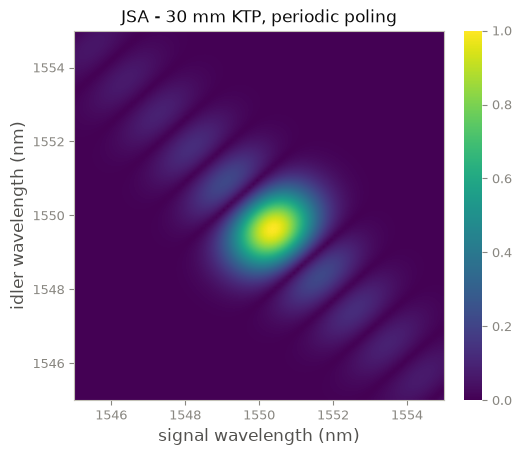

In [5]:
grid = SPDCGridConfig(steps=100, dev_nm=5.0)
simulation = SPDC_Simulation(crystal, laser, grid=grid)
results_periodic = simulation.run()

fig, ax = plt.subplots()
SPDC_Plotter(results_periodic).plot_result(key="JSA", fig=fig, ax=ax)
ax.set_title("JSA - 30 mm KTP, periodic poling")
plt.show()

## Heralding purity: why that streaked structure matters

If you detect ("herald") the idler photon, the signal photon collapses to whatever spectral mode is
correlated with the detected idler frequency. If the JSA were *separable*,
$f(\omega_s,\omega_i) = g(\omega_s)h(\omega_i)$, every heralding event would leave the signal in
the *same* spectral mode: a pure heralded single photon. Any structure that correlates $\omega_s$
with $\omega_i$ — like the diagonal streaks above — reduces that purity.

The **Schmidt decomposition**
$f(\omega_s,\omega_i)=\sum_k \sqrt{\lambda_k}\,\phi_k(\omega_s)\psi_k(\omega_i)$ quantifies this
exactly: the **purity** $P=\sum_k \lambda_k^2$ equals $1$ for a perfectly separable JSA and drops as
more Schmidt modes contribute. (see Graffitti *et al.* **[[2]](#ref2)**, section 2, for the formal derivation).

In [6]:
schmidt_coeffs, purity_periodic, K_periodic = SpectralAnalyzer(results_periodic).schmidt_decomposition()
print(f"Purity (30 mm, periodic poling): {purity_periodic:.3f}")
print(f"Effective Schmidt number K = 1/purity: {K_periodic:.3f}")

Purity (30 mm, periodic poling): 0.762
Effective Schmidt number K = 1/purity: 1.313


Let's look past the single purity number: plotting the Schmidt coefficients themselves shows how
many modes actually contribute (a purity of ~0.76 already tells us it's not just one), and the
signal/idler marginal spectra (the JSI summed over the other photon's wavelength, with Gaussian fits
overlaid) show what each photon looks like on its own.

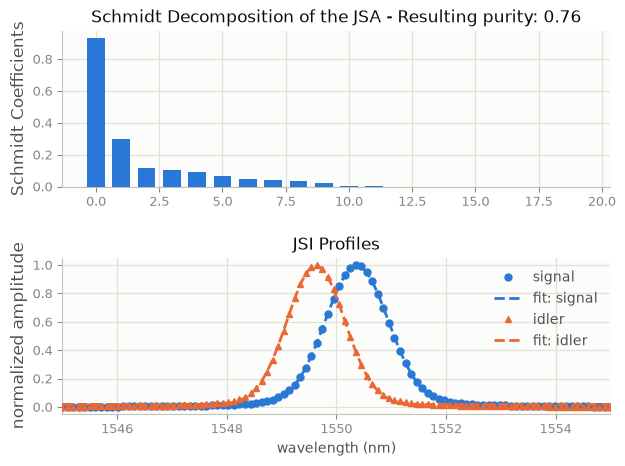

In [7]:
plotter = SPDC_Plotter(results_periodic)
fig = plt.figure()
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212)
plotter.plot_schmidt_coefficients(fig=fig, ax=ax1)
plotter.plot_signal_idler_spectra(fig=fig, ax=ax2)
fig.tight_layout(pad=1.2, w_pad=2, h_pad=2.0)
plt.show()

A purity around three-quarters means roughly a quarter of heralded photons come out in the
"wrong" spectral mode compared to the rest — bad news for interference experiments that need
photons indistinguishable from each other. Where does that streaked structure come from, and can we
remove it?

## Fixing it: sub-coherence-length domain engineering

A plain periodic grating is a *rectangular* window: the nonlinearity switches abruptly between
$+1$ and $-1$ right up to the crystal's edges. Like any rectangular window, its Fourier transform
(here, the phase-matching function $\phi(\Delta k)$) has pronounced side-lobes — exactly the
diagonal streaks we just saw, and exactly what limits the purity above.

Graffitti *et al.* **[[2]](#ref2)** showed you can shape $\phi(\Delta k)$ directly by tapering the poled nonlinearity's *envelope*
towards a Gaussian near the crystal's ends, instead of leaving it rectangular — which suppresses the
side-lobes at their source. Their trick: discretize the crystal into domains *much narrower* than
$L_c$ (hence "sub-coherence-length"), and greedily choose each domain's orientation, one at a time,
to best track a smoothly-apodized target amplitude. `photonpairlab` implements this as
`mode="subcoh"`. Let's build a second crystal — same length, same target wavelengths, same
wavelength grid, only the poling pattern differs — and compare directly against
`results_periodic` from above.

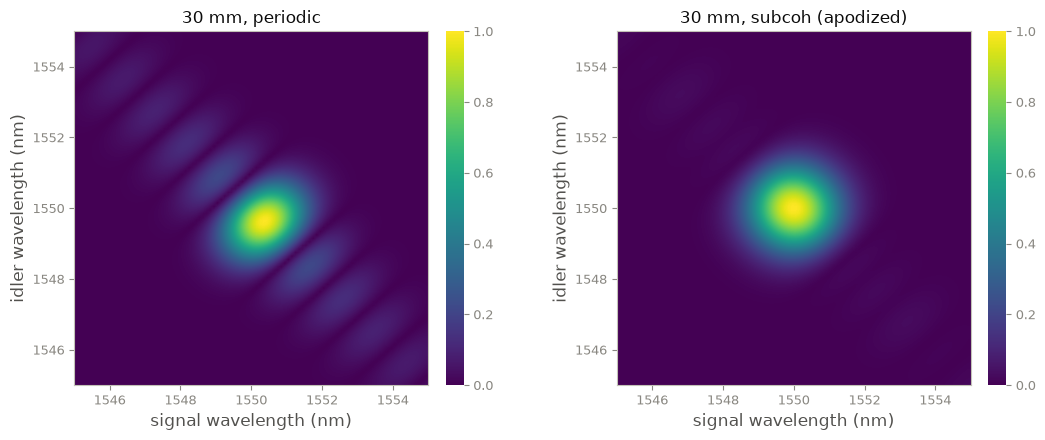

Purity, periodic: 0.762
Purity, subcoh:   0.992


In [8]:
crystal_subcoh = Crystal(crystal_length=crystal_length, material=material,
                          pm_strategy="quasi", spdc_type="type-II", T=20.0, w=18e-6)
crystal_subcoh.generate_poling(laser=laser, mode="subcoh",
                                wavelength_signal=1550e-9, wavelength_idler=1550e-9)
results_subcoh = SPDC_Simulation(crystal_subcoh, laser, grid=grid).run()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
SPDC_Plotter(results_periodic).plot_result(key="JSA", fig=fig, ax=axes[0])
axes[0].set_title("30 mm, periodic")
SPDC_Plotter(results_subcoh).plot_result(key="JSA", fig=fig, ax=axes[1])
axes[1].set_title("30 mm, subcoh (apodized)")
plt.tight_layout()
plt.show()

_, purity_subcoh, _ = SpectralAnalyzer(results_subcoh).schmidt_decomposition()
print(f"Purity, periodic: {purity_periodic:.3f}")
print(f"Purity, subcoh:   {purity_subcoh:.3f}")

Before looking at what apodization did for the JSA, it's worth checking what it did to the poling
pattern itself. `crystal_subcoh.generate_poling(...)` didn't just pick domain orientations — along
the way it also tracked the **target field amplitude** (the smooth Gaussian envelope it's trying to
approximate) against the **actual field amplitude** the discrete, sub-coherence-length domain
pattern actually builds up to. `SPDC_Plotter.plot_poling_profile` plots both, with the domain
pattern itself shown as a bar-code strip underneath — this works for any crystal, not just apodized
ones (try it on `crystal` from the periodic-poling section above, or on `results_apm`'s unpoled
crystal, for contrast).

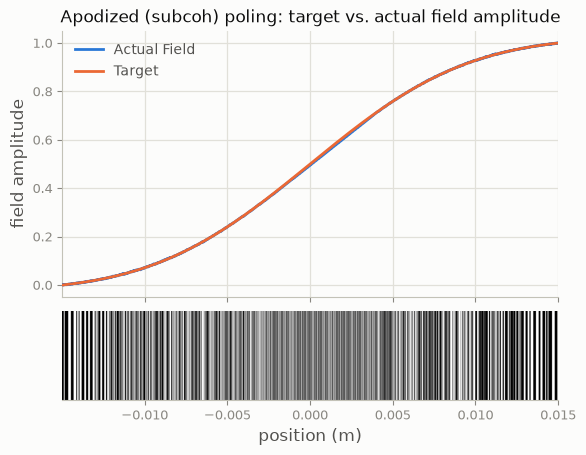

In [9]:
fig, (field_ax, pattern_ax) = SPDC_Plotter.plot_poling_profile(crystal_subcoh)
field_ax.set_title("Apodized (subcoh) poling: target vs. actual field amplitude")
plt.show()

The apodized crystal's JSA is visibly cleaner — a single round blob instead of a comb of
diagonal streaks — and its purity is close to unity. Same crystal, same target wavelengths, just a
different poling pattern.

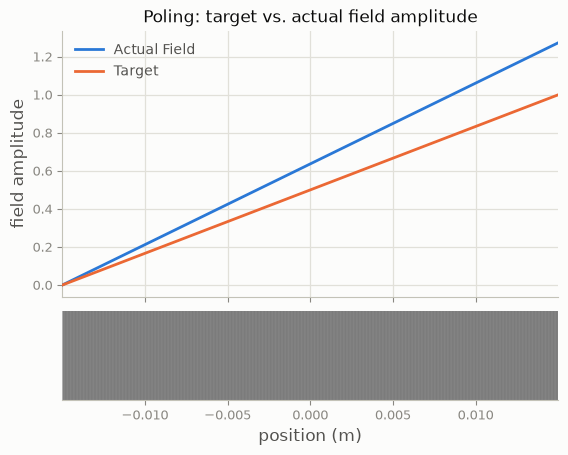

In [10]:
fig, (field_ax, pattern_ax) = SPDC_Plotter.plot_poling_profile(crystal=crystal)
field_ax.set_title("Poling: target vs. actual field amplitude")
plt.show()

For the plain periodic grating, `target` isn't an apodization envelope at all — with no
intentional taper to track, it's just the idealized *continuous* nonlinearity $\cos(\pi z/L_c)$ a
perfect QPM grating would realize, normalized to a flat $g(z)=1$. `actual`, on the other hand, is
what the discrete $\pm1$ square-wave domain pattern really builds up to, and a square wave's
fundamental Fourier component is $4/\pi\approx1.27\times$ the amplitude of a pure sinusoid with the
same peak — so `actual` runs $4/\pi$ above `target` here, growing at a visibly steeper slope rather
than tracking it. That's expected, not a bug: it's the same rectangular-window effect responsible
for the side-lobes (and the purity-limiting streaks) above, and precisely the gap sub-coherence-
length apodization closes by choosing domain signs to track a target instead of ignoring it.

## Hong-Ou-Mandel interference between two independent sources

If we bring the signal photons from **two independent** SPDC sources (or the same source, run
twice) together on a balanced beamsplitter, the coincidence-detection probability as a function of
relative time delay $\tau$ is

$$P_c(\tau) = R^2+T^2 - 2RT\,\mathrm{Re}\big[\mathrm{Tr}(\rho_1\,\rho_2(\tau))\big],$$

which, for a 50:50 beamsplitter ($R=T=\tfrac12$), dips to
$P_c(0)=\tfrac12\big(1-\mathrm{Tr}(\rho_1\rho_2)\big)$ at zero delay when the two heralded photons
are prepared in the reduced spectral states $\rho_{1,2}$. A **fully visible dip**
($P_c(0)=0$) requires those heralded photons to be in the *same pure* spectral state — precisely
the purity we computed above. (See Brańczyk **[[3]](#ref3)** for a pedagogical
derivation of this formula.) Let's compare the dip for our periodic vs. apodized 30 mm sources.

(We hand `compute_two_mode_HOM` an explicit, narrow delay window here: its default range is set
from the wavelength grid's frequency spacing and, for a periodic grating, is wide enough to also
show the *revivals* of the dip caused by the grating's own periodicity — real physics, but a
distraction from the single central dip we want to focus on first.)

          periodic: minimum coincidence probability = 0.1192
 subcoh (apodized): minimum coincidence probability = 0.0039


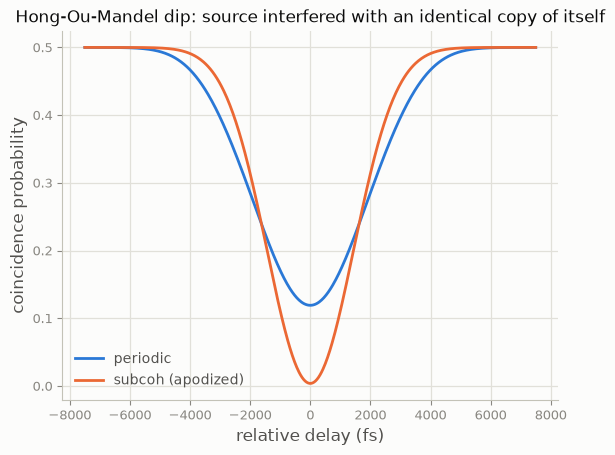

In [11]:
taus_s = np.linspace(-7500e-15, 7500e-15, 601)

hom_results = {}
for label, results in [("periodic", results_periodic), ("subcoh (apodized)", results_subcoh)]:
    hom = HOMAnalyzer(results, results)
    hom_results[label] = hom.compute_two_mode_HOM(mode1="signal", mode2="signal", taus_s=taus_s)
    print(f"{label:>18s}: minimum coincidence probability = {hom_results[label].coincidence_probabilities.min():.4f}")

fig, ax = SPDC_Plotter.plot_hom_dip(hom_results)
ax.set_title("Hong-Ou-Mandel dip: source interfered with an identical copy of itself")
plt.show()

The apodized source's dip goes almost all the way to zero — near-perfect indistinguishability
between the two (independently generated) heralded photons — while the periodic source's residual
spectral correlations leave a visible floor at zero delay.

## Tuning to a target wavelength: temperature

Refractive index depends on temperature (the thermo-optic effect), so $\Delta k$ — and hence which
signal/idler wavelength pair is exactly phase-matched for a fixed pump — shifts with crystal
temperature. This is normally how a source gets fine-tuned to a specific wavelength channel without
re-poling the crystal. Because the Sellmeier temperature correction has a $\Delta T^2$ term, this
tuning curve is **not linear**: fitting it with a straight line (a tempting first guess) gives a
biased estimate of where the signal and idler curves actually cross at degeneracy, so we fit a
quadratic instead.

This is also a good place to reach for `simulate_spdc`: it bundles the material lookup, crystal and
laser construction, poling generation, and simulation run into one call, which is much less
repetitive than rebuilding all of that by hand for every temperature in a sweep.

One subtlety: a tuning curve is about how *one fixed grating* performs away from the temperature it
was designed for, so we deliberately pass the *same* `coherence_length` — the one computed earlier
for our original 30 mm crystal at 20 °C — to every point in the sweep, rather than letting
`simulate_spdc` auto-compute a fresh "ideal" one at each temperature (which would silently
re-optimize the poling at every point and erase the very effect we're trying to see).

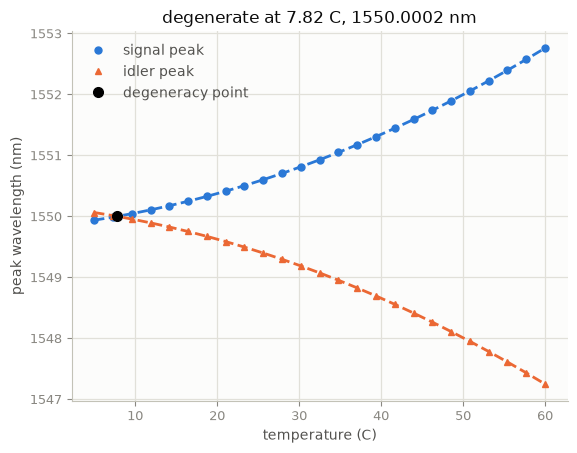

In [12]:
temperatures = np.linspace(5, 60, 25)
signal_peaks, idler_peaks = [], []

for T in temperatures:
    results = simulate_spdc(
        material_name="ktp1", crystal_length=crystal_length,
        wavelength_pump=pump_wavelength, pulse_duration=pulse_duration, T=T,
        coherence_length=crystal.coherence_length,  # fixed grating, from the 20 C design point
    )
    s_peak, i_peak, _, _ = SpectralAnalyzer(results).get_signal_idler_peaks(method="quadratic")
    signal_peaks.append(s_peak)
    idler_peaks.append(i_peak)

signal_peaks = np.array(signal_peaks)
idler_peaks = np.array(idler_peaks)

popt_signal, _ = quadratic_fit(temperatures, signal_peaks)
popt_idler, _ = quadratic_fit(temperatures, idler_peaks)
T_degenerate, wl_degenerate = quadratic_intersection_coordinates(
    *popt_signal, *popt_idler, x_range=(temperatures.min(), temperatures.max())
)

signal_color, idler_color = SPDC_Plotter.SERIES_COLORS[0], SPDC_Plotter.SERIES_COLORS[1]

fig, ax = plt.subplots()
ax.plot(temperatures, signal_peaks, "o", color=signal_color, markersize=5, label="signal peak")
ax.plot(temperatures, quadratic(temperatures, *popt_signal), "--", color=signal_color, linewidth=2)
ax.plot(temperatures, idler_peaks, "^", color=idler_color, markersize=5, label="idler peak")
ax.plot(temperatures, quadratic(temperatures, *popt_idler), "--", color=idler_color, linewidth=2)
ax.plot(T_degenerate, wl_degenerate, "o", color="black", markersize=7, label="degeneracy point")
ax.set_xlabel("temperature (C)")
ax.set_ylabel("peak wavelength (nm)")
ax.set_title(f"degenerate at {T_degenerate:.2f} C, {wl_degenerate:.4f} nm")
SPDC_Plotter.style_axes(ax)
ax.legend(frameon=False, labelcolor="#52514e")
plt.show()

## An alternative: angle (birefringent) phase-matching

Not every application wants a periodically-poled crystal — angle phase-matching needs no poling at
all, trading that simplicity for a fixed relationship between phase-matching angle and wavelength
(and for walk-off between the differently-polarized beams). `photonpairlab` supports it via
`pm_strategy="angle"`; for BiBO's `type-IIoeo` process, the phase-matching angle itself is found
automatically by minimizing $|\Delta k(\theta)|$ — you don't need to look it up or supply it.

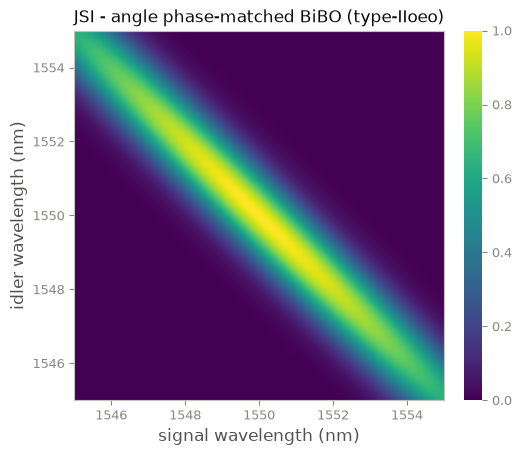

In [13]:
results_apm = simulate_spdc(
    material_name="bibo",
    crystal_length=4e-3,
    wavelength_pump=775e-9,
    pulse_duration=1.7e-12,
    spdc_type="type-IIoeo",
    pm_strategy="angle",
    poling_mode="constant",
    w=50e-6,
    T=25.0,
)

fig, ax = plt.subplots()
SPDC_Plotter(results_apm).plot_result(key="JSI", fig=fig, ax=ax)
ax.set_title("JSI - angle phase-matched BiBO (type-IIoeo)")
plt.show()

Notice the shape: a thin stripe along the anti-diagonal, rather than the round blob we designed
for the QPM examples above. That elongation is spectral correlation between signal and idler — this
particular BiBO cut/angle isn't *group-velocity matched*, so $\omega_s+\omega_i=\omega_p$ (fixed by
the pump envelope) and the crystal's own phase-matching condition aren't tilted the same way in
$(\omega_s,\omega_i)$ space.

## Finding a group-velocity-matched point

"Choosing wavelengths where they align" is a real search, not a hand-wave — let's actually do it.
There are two flavors of **group-velocity matching (GVM)**:

- **Asymmetric**: match the pump's group index to *one* photon's, $N_p = N_s$. This makes the
  phase-matching function depend on $\omega_i$ alone, removing the tilt — but the result is still an
  axis-aligned *ellipse*, not a circle, since the phase-matching ridge (running along one wavelength
  axis) and the pump's ridge (running along the anti-diagonal) still aren't orthogonal to each other.
- **Symmetric**: match the pump's group index to the *average* of both, $N_p = (N_s+N_i)/2$. This
  makes the phase-matching function depend on $(\omega_s-\omega_i)$ specifically — a direction that
  *is* orthogonal to the pump's $(\omega_s+\omega_i)$ constraint. Only this version can give a
  genuinely circular JSA (once the widths are also matched).

Let's try the simpler, asymmetric one first — it's a 1D search over pump wavelength alone — and see
exactly what it does and doesn't fix.

(Both flavors are used in real telecom-photon sources today — see Cai *et al.* **[[5]](#ref5)** for GVM-based poling optimization, and Faleo *et al.* **[[4]](#ref4)** for combining GVM-style pump shaping with nonlinearity apodization.)

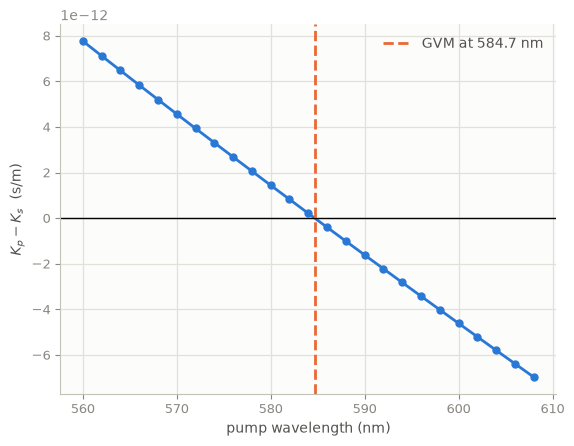

Group-velocity-matched pump wavelength: 584.69 nm (degenerate at 1169.38 nm)


In [14]:
from photonpairlab.crystal.phasematching.apm_strategy import APMPhaseMatching
from photonpairlab.laser import CWLaser
from photonpairlab.constants import C_VAC

bbo = MaterialFactory.create("bbo")
apm_bbo = APMPhaseMatching(bbo, spdc_type="type-IIeoe")

pump_candidates_nm = np.arange(560, 610, 2.0)
group_index_mismatch = []
for pump_nm in pump_candidates_nm:
    scan_pump = pump_nm * 1e-9
    scan_laser = CWLaser(scan_pump, bandwidth_wavelength=1e-9)
    pm_result = apm_bbo.compute_phase_mismatch(scan_laser, 2 * scan_pump, 2 * scan_pump, T=25.0)
    N_pump, N_signal, N_idler = pm_result.N
    group_index_mismatch.append((N_pump - N_signal) / C_VAC)

group_index_mismatch = np.array(group_index_mismatch)
# Linear interpolation for the zero crossing of Kp - Ks
crossing_idx = np.where(np.diff(np.sign(group_index_mismatch)))[0][0]
x0, x1 = pump_candidates_nm[crossing_idx], pump_candidates_nm[crossing_idx + 1]
y0, y1 = group_index_mismatch[crossing_idx], group_index_mismatch[crossing_idx + 1]
gvm_pump_nm = x0 - y0 * (x1 - x0) / (y1 - y0)

fig, ax = plt.subplots()
ax.plot(pump_candidates_nm, group_index_mismatch, "o-", color=SPDC_Plotter.SERIES_COLORS[0], markersize=5, linewidth=2)
ax.axhline(0, color="black", lw=1)
ax.axvline(gvm_pump_nm, color=SPDC_Plotter.SERIES_COLORS[1], ls="--", linewidth=2, label=f"GVM at {gvm_pump_nm:.1f} nm")
ax.set_xlabel("pump wavelength (nm)")
ax.set_ylabel(r"$K_p - K_s$  (s/m)")
SPDC_Plotter.style_axes(ax)
ax.legend(frameon=False, labelcolor="#52514e")
plt.show()

print(f"Group-velocity-matched pump wavelength: {gvm_pump_nm:.2f} nm "
      f"(degenerate at {2*gvm_pump_nm:.2f} nm)")

### Aside: the same scan, batched with JAX (optional)

The loop above calls `compute_phase_mismatch` once per candidate pump wavelength; each call runs
its own `scipy.optimize` angle search plus a finite-difference group index. If you've installed the
optional `jax` extra (`pip install photonpairlab[jax]`), `APMPhaseMatching` also exposes a batched
counterpart, `compute_phase_mismatch_jax`, that JIT-compiles the whole sweep into a single call.
It's numerically equivalent to the loop above (checked below) and, once compiled, substantially
faster for sweeps like this one.

In [15]:
try:
    import time

    import jax.numpy as jnp  # noqa: F401

    pump_m = pump_candidates_nm * 1e-9

    apm_bbo.compute_phase_mismatch_jax(pump_m, 2 * pump_m, 2 * pump_m, T=25.0)  # warm up: pays the one-time JIT compile cost

    t0 = time.perf_counter()
    for pump_nm in pump_candidates_nm:
        scan_pump = pump_nm * 1e-9
        scan_laser = CWLaser(scan_pump, bandwidth_wavelength=1e-9)
        apm_bbo.compute_phase_mismatch(scan_laser, 2 * scan_pump, 2 * scan_pump, T=25.0)
    t_loop = time.perf_counter() - t0

    t0 = time.perf_counter()
    batch = apm_bbo.compute_phase_mismatch_jax(pump_m, 2 * pump_m, 2 * pump_m, T=25.0)
    t_jax = time.perf_counter() - t0

    N_pump_jax, N_signal_jax, _ = batch["N"]
    group_index_mismatch_jax = np.asarray((N_pump_jax - N_signal_jax) / C_VAC)

    print(f"Python loop (scipy):    {t_loop * 1e3:6.2f} ms")
    print(f"JAX batched (compiled): {t_jax * 1e3:6.2f} ms  ({t_loop / t_jax:.0f}x faster)")
    print(f"max deviation from loop result: {np.max(np.abs(group_index_mismatch_jax - group_index_mismatch)):.3e}")
except ImportError:
    print("Install the optional 'jax' extra (`pip install photonpairlab[jax]`) to run this cell.")

Python loop (scipy):      4.01 ms
JAX batched (compiled):   0.24 ms  (17x faster)
max deviation from loop result: 5.152e-16


With that pump wavelength in hand, the other requirement mentioned back at the start of this
section is to also match the *widths* of the pump envelope and the phase-matching function — not
just their tilt. A shorter pump pulse (broader pump bandwidth) trades against a shorter crystal
(broader phase-matching bandwidth); we'll just try a short crystal with a short pulse.

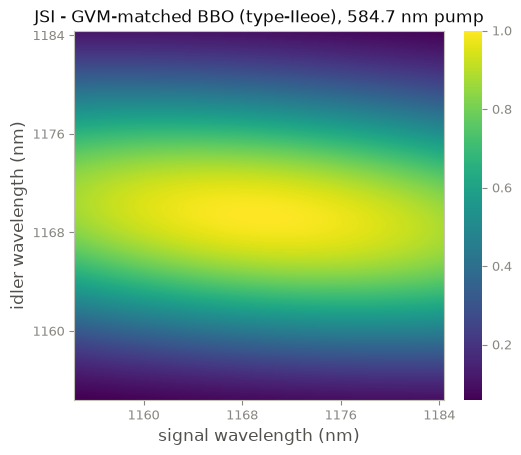

Purity, GVM-matched BBO example: 0.998


In [16]:
results_apm_gvm = simulate_spdc(
    material_name="bbo",
    crystal_length=2e-3,
    wavelength_pump=gvm_pump_nm * 1e-9,
    pulse_duration=30e-15,
    spdc_type="type-IIeoe",
    pm_strategy="angle",
    poling_mode="constant",
    w=50e-6,
    T=25.0,
    grid=SPDCGridConfig(steps=100, dev_nm=15.0),
)

fig, ax = plt.subplots()
SPDC_Plotter(results_apm_gvm).plot_result(key="JSI", fig=fig, ax=ax)
ax.set_title(f"JSI - GVM-matched BBO (type-IIeoe), {gvm_pump_nm:.1f} nm pump")
plt.show()

_, purity_apm_gvm, _ = SpectralAnalyzer(results_apm_gvm).schmidt_decomposition()
print(f"Purity, GVM-matched BBO example: {purity_apm_gvm:.3f}")

Flat and axis-aligned rather than tilted, and purity above 99% — matching the pump's group
velocity to the signal's removes the *correlation* without needing any nonlinearity apodization at
all. But look at the shape again: it's still an ellipse, elongated along $\omega_s$ (the pump's own
bandwidth direction), not a circle. That's expected: asymmetric GVM removes the tilt, but the
phase-matching ridge (a function of $\omega_i$ alone) and the pump's ridge (a function of
$\omega_s+\omega_i$) still aren't orthogonal to each other, so there's no reason for the two widths
to combine into rotational symmetry.

## Getting an actual circular blob: symmetric GVM

Let's redo the search for the symmetric condition, $N_p = (N_s+N_i)/2$, instead.

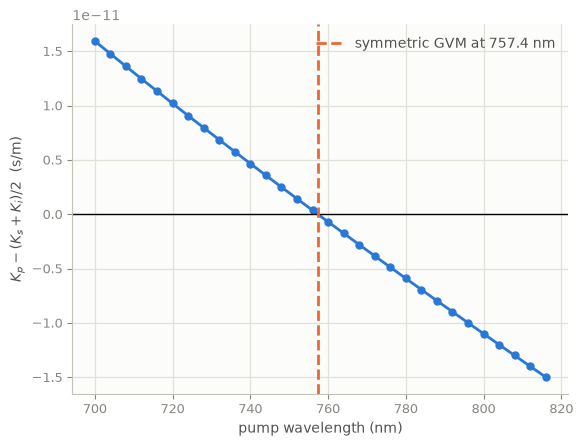

Symmetric-GVM pump wavelength: 757.36 nm (degenerate at 1514.73 nm)


In [17]:
apm_bbo_sym = APMPhaseMatching(bbo, spdc_type="type-IIeoe")

pump_candidates_nm = np.arange(700, 820, 4.0)
sym_mismatch = []
for pump_nm in pump_candidates_nm:
    scan_pump = pump_nm * 1e-9
    scan_laser = CWLaser(scan_pump, bandwidth_wavelength=1e-9)
    pm_result = apm_bbo_sym.compute_phase_mismatch(scan_laser, 2 * scan_pump, 2 * scan_pump, T=25.0)
    N_pump, N_signal, N_idler = pm_result.N
    sym_mismatch.append((N_pump - (N_signal + N_idler) / 2) / C_VAC)

sym_mismatch = np.array(sym_mismatch)
crossing_idx = np.where(np.diff(np.sign(sym_mismatch)))[0][0]
x0, x1 = pump_candidates_nm[crossing_idx], pump_candidates_nm[crossing_idx + 1]
y0, y1 = sym_mismatch[crossing_idx], sym_mismatch[crossing_idx + 1]
sym_gvm_pump_nm = x0 - y0 * (x1 - x0) / (y1 - y0)

fig, ax = plt.subplots()
ax.plot(pump_candidates_nm, sym_mismatch, "o-", color=SPDC_Plotter.SERIES_COLORS[0], markersize=5, linewidth=2)
ax.axhline(0, color="black", lw=1)
ax.axvline(sym_gvm_pump_nm, color=SPDC_Plotter.SERIES_COLORS[1], ls="--", linewidth=2, label=f"symmetric GVM at {sym_gvm_pump_nm:.1f} nm")
ax.set_xlabel("pump wavelength (nm)")
ax.set_ylabel(r"$K_p - (K_s+K_i)/2$  (s/m)")
SPDC_Plotter.style_axes(ax)
ax.legend(frameon=False, labelcolor="#52514e")
plt.show()

print(f"Symmetric-GVM pump wavelength: {sym_gvm_pump_nm:.2f} nm "
      f"(degenerate at {2*sym_gvm_pump_nm:.2f} nm)")

Same width-matching requirement as before, but there's an extra subtlety worth being explicit
about: heralded-photon purity computed on a finite simulation grid is sensitive to *how wide a
window* you evaluate it on — too narrow can hide real structure (or even give a misleadingly high
number), too wide risks numerically under-resolving the state. We picked the crystal length/pulse
duration below by checking that the resulting purity is stable across a few different window sizes,
not just whichever one happened to look good first.

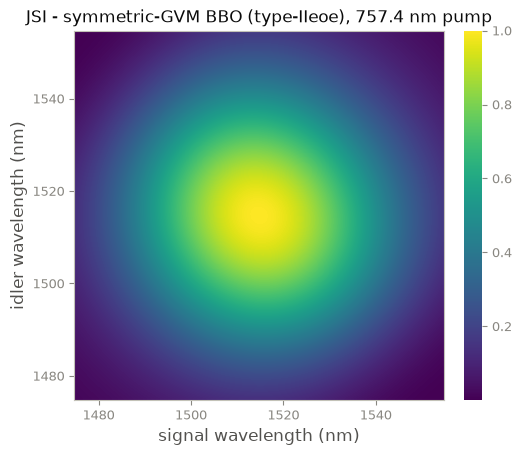

Purity, symmetric-GVM BBO example: 0.9980
Purity on a 2x wider window (robustness check): 0.9980


In [18]:
results_apm_sym = simulate_spdc(
    material_name="bbo",
    crystal_length=2e-3,
    wavelength_pump=sym_gvm_pump_nm * 1e-9,
    pulse_duration=50e-15,
    spdc_type="type-IIeoe",
    pm_strategy="angle",
    poling_mode="constant",
    w=50e-6,
    T=25.0,
    grid=SPDCGridConfig(steps=120, dev_nm=40.0),
)

fig, ax = plt.subplots()
SPDC_Plotter(results_apm_sym).plot_result(key="JSI", fig=fig, ax=ax)
ax.set_title(f"JSI - symmetric-GVM BBO (type-IIeoe), {sym_gvm_pump_nm:.1f} nm pump")
plt.show()

_, purity_apm_sym, _ = SpectralAnalyzer(results_apm_sym).schmidt_decomposition()
print(f"Purity, symmetric-GVM BBO example: {purity_apm_sym:.4f}")

# Robustness check: does the purity survive a much wider evaluation window?
wide_results = simulate_spdc(
    material_name="bbo", crystal_length=2e-3, wavelength_pump=sym_gvm_pump_nm * 1e-9,
    pulse_duration=50e-15, spdc_type="type-IIeoe", pm_strategy="angle",
    poling_mode="constant", w=50e-6, T=25.0,
    grid=SPDCGridConfig(steps=120, dev_nm=40.0),
)
_, purity_wide, _ = SpectralAnalyzer(wide_results).schmidt_decomposition()
print(f"Purity on a 2x wider window (robustness check): {purity_wide:.4f}")

An actual circular blob — and the purity holds up on a wider window too, so this isn't a plotting
artifact. Matching the pump's group velocity to the *average* of the signal and idler's is what
makes the phase-matching function depend on $(\omega_s-\omega_i)$, orthogonal to the pump's own
$(\omega_s+\omega_i)$ constraint; with the widths also matched, the two combine into a state that's
symmetric under rotation in $(\omega_s,\omega_i)$ — genuinely separable, not just uncorrelated along
one particular axis.

## Where to go from here

- `tests/` has focused regression tests for every piece of physics touched in this notebook — a
  good place to see edge cases and exact expected values (e.g. `tests/tests_crystal/test_bbo.py`,
  `tests/tests_spdc/test_analysis.py`, `tests/tests_spdc/test_hom.py`).
- `notebooks/tests.ipynb` is a smaller scratch notebook for quick one-off checks.
- The `Crystal`, `SPDC_Simulation`, and `SpectralAnalyzer`/`HOMAnalyzer` docstrings cover parameters
  not exercised here — other SPDC types (`type-I`, `type-0`), `mode="constant"` poling for QPM, and
  `SPDCGridConfig`'s explicit `signal_range`/`idler_range` for asymmetric (non-degenerate) grids.

## References

For readers who want to go deeper — all five are freely available:

1. <a id="ref1"></a>C. Couteau, "Spontaneous parametric down-conversion," *Contemporary Physics* **59**, 291 (2018).
   [arXiv:1809.00127](https://arxiv.org/abs/1809.00127) — a broad introduction to SPDC theory
   (energy/momentum conservation, phase matching, QPM) and its applications.

2. <a id="ref2"></a>F. Graffitti, D. Kundys, D. T. Reid, A. M. Brańczyk, A. Fedrizzi, "Pure down-conversion photons
   through sub-coherence-length domain engineering," *Quantum Science and Technology* **2**, 035001
   (2017). [arXiv:1704.03683](https://arxiv.org/abs/1704.03683) — derives the JSA/phase-matching-
   function/Schmidt-purity formalism used throughout this notebook, and introduces the
   sub-coherence-length domain-engineering algorithm implemented here as `mode="subcoh"`.

3. <a id="ref3"></a>A. M. Brańczyk, "Hong-Ou-Mandel Interference" (2017).
   [arXiv:1711.00080](https://arxiv.org/abs/1711.00080) — a pedagogical derivation of the HOM
   coincidence-probability formula for pure, mixed, and spectrally entangled photon states.

4. <a id="ref4"></a>T. Faleo, C. L. Morrison, R. Beignon, F. Graffitti, V. Remesh, S. Frick, A. Fedrizzi, G. Weihs,
   R. Keil, "Optimised spectral purity of unfiltered photons via pump and nonlinearity shaping"
   (2025). [arXiv:2510.06196](https://arxiv.org/abs/2510.06196) — combines Gaussian poling *and*
   pump shaping (apodization and width-matching together, the same two ingredients used separately
   in this notebook) to reach >99.9% spectral purity without any filtering.

5. <a id="ref5"></a>W.-H. Cai, S. Baek, R.-B. Jin, F. Kaneda, "Optimized Spectral Purity of Heralded Single Photons
   at the Telecom O-Band" (2025). [arXiv:2501.14214](https://arxiv.org/abs/2501.14214) —
   group-velocity matching and poling optimization for high-purity telecom-band sources, in the same
   spirit as the symmetric-GVM search in this notebook.